# Environment and Config Setup

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import mannwhitneyu
from statsmodels.stats import multitest

# Paths
DNV_PATH   = "/path/to/data/variant.feather"
ASD_CSV    = "/path/to/data/table.NDD_gene_list.csv"
ATTN_ROOT  = "/path/to/attn"
PROB_ROOT  = "/path/to/probs"
SAVE_DIR   = "./results/attention_heatmap"
os.makedirs(SAVE_DIR, exist_ok=True)

# Config
TARGET_FRAC = 0.20
MODEL_KEYS = ["dnabert", "dnabert2", "ntv2", "ntv3", "hyenadna", "evo2", "phylogpn"]
TASK_KEYS  = ["ZS", "ClinVar", "gnomAD", "BEND", "NCRE"]

MODEL_LABEL = {
    "dnabert": "DNABERT", "dnabert2": "DNABERT-2", "ntv2": "NT V2", 
    "ntv3": "NT V3", "evo2": "Evo 2", "hyenadna": "HyenaDNA", "phylogpn": "PhyloGPN"
}

TASK_DISPLAY_MAP = {
    "ZS": "Zero-shot", "ClinVar": "ClinVar Missense", "gnomAD": "gnomAD Variants", 
    "BEND": "BEND Non-coding", "NCRE": "Regulatory Elements"
}

mpl.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42, "axes.linewidth": 0.8})

# Attention score loading

In [ ]:
# DNABERT
zs_dnabert_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/dnabert_zs_attn.csv")
ft_dnabert_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_ncre_attn.csv")
ft_dnabert_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_bend_attn.csv")
ft_dnabert_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_clinvar_attn.csv")
ft_dnabert_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_gnomad_attn.csv")

# DNABERT2
zs_dnabert2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/dnabert2_zs_attn.csv")
ft_dnabert2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_ncre_attn.csv")
ft_dnabert2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_bend_attn.csv")
ft_dnabert2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_clinvar_attn.csv")
ft_dnabert2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_gnomad_attn.csv")

# NTv2
zs_ntv2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/ntv2_zs_attn.csv")
ft_ntv2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_ncre_attn.csv")
ft_ntv2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_bend_attn.csv")
ft_ntv2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_clinvar_attn.csv")
ft_ntv2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_gnomad_attn.csv")

# NTv3
zs_ntv3_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/ntv3_zs_attn.csv")
ft_ntv3_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_ncre_attn.csv")
ft_ntv3_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_bend_attn.csv")
ft_ntv3_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_clinvar_attn.csv")
ft_ntv3_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_gnomad_attn.csv")

# HyenaDNA
zs_hyena_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/hyenadna_zs_attn.csv")
ft_hyena_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_ncre_attn.csv")
ft_hyena_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_bend_attn.csv")
ft_hyena_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_clinvar_attn.csv")
ft_hyena_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_gnomad_attn.csv")

# Evo 2
zs_evo2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/evo2_zs_attn.csv")
ft_evo2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_ncre_attn.csv")
ft_evo2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_bend_attn.csv")
ft_evo2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_clinvar_attn.csv")
ft_evo2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_gnomad_attn.csv")

# PhyloGPN
zs_phylogpn_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/phylogpn_zs_attn.csv")
ft_phylogpn_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_ncre_attn.csv")
ft_phylogpn_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_bend_attn.csv")
ft_phylogpn_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_clinvar_attn.csv")
ft_phylogpn_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_gnomad_attn.csv")

model_tasks_attn = {
    "dnabert":  {"ZS": zs_dnabert_attn,  "NCRE": ft_dnabert_ncre_attn,  "BEND": ft_dnabert_bend_attn,  "ClinVar": ft_dnabert_clinvar_attn,  "gnomAD": ft_dnabert_gnomad_attn},
    "dnabert2": {"ZS": zs_dnabert2_attn, "NCRE": ft_dnabert2_ncre_attn, "BEND": ft_dnabert2_bend_attn, "ClinVar": ft_dnabert2_clinvar_attn, "gnomAD": ft_dnabert2_gnomad_attn},
    "ntv2":     {"ZS": zs_ntv2_attn,     "NCRE": ft_ntv2_ncre_attn,     "BEND": ft_ntv2_bend_attn,     "ClinVar": ft_ntv2_clinvar_attn,     "gnomAD": ft_ntv2_gnomad_attn},
    "ntv3":     {"ZS": zs_ntv3_attn,     "NCRE": ft_ntv3_ncre_attn,     "BEND": ft_ntv3_bend_attn,     "ClinVar": ft_ntv3_clinvar_attn,     "gnomAD": ft_ntv3_gnomad_attn},
    "hyenadna": {"ZS": zs_hyena_attn,    "NCRE": ft_hyena_ncre_attn,    "BEND": ft_hyena_bend_attn,    "ClinVar": ft_hyena_clinvar_attn,    "gnomAD": ft_hyena_gnomad_attn},
    "evo2":     {"ZS": zs_evo2_attn,     "NCRE": ft_evo2_ncre_attn,     "BEND": ft_evo2_bend_attn,     "ClinVar": ft_evo2_clinvar_attn,     "gnomAD": ft_evo2_gnomad_attn},
    "phylogpn": {"ZS": zs_phylogpn_attn, "NCRE": ft_phylogpn_ncre_attn, "BEND": ft_phylogpn_bend_attn, "ClinVar": ft_phylogpn_clinvar_attn, "gnomAD": ft_phylogpn_gnomad_attn},
}

# Core processing functions

In [ ]:
def clr_transform(df):
    df = df.copy()
    for col in ["SAMPLE", "sample_idx", "sample_id"]:
        if col in df.columns:
            df = df.rename(columns={col: "vcf_iid"})
    df = df.dropna(subset=["vcf_iid", "variant", "attention"]).copy()
    df["vcf_iid"] = df["vcf_iid"].astype(str)
    
    a = pd.to_numeric(df["attention"], errors="coerce").fillna(1e-12).to_numpy(dtype=float)
    df["_log"] = np.log(np.clip(a, 1e-12, None))
    df["attention_clr"] = df["_log"] - df.groupby("vcf_iid")["_log"].transform("mean")
    return df

def compute_sample_delta(attn_df, dnv_df, known_genes):
    attn_df = clr_transform(attn_df)
    merged = attn_df.merge(dnv_df[["vcf_iid", "variant", "gene_symbol"]], on=["vcf_iid", "variant"], how="inner")
    merged["gene_symbol"] = merged["gene_symbol"].astype(str).str.upper()
    
    in_set = merged["gene_symbol"].isin(known_genes)
    g_in = merged.loc[in_set].groupby("vcf_iid")["attention_clr"].mean().rename("mean_in")
    g_ot = merged.loc[~in_set].groupby("vcf_iid")["attention_clr"].mean().rename("mean_out")
    
    out = pd.concat([g_in, g_ot], axis=1).dropna().reset_index()
    out["delta"] = out["mean_in"] - out["mean_out"]
    return out

# Main analysis execution (20% fraction)

In [ ]:
dnv = pd.read_feather(DNV_PATH)
dnv["vcf_iid"] = dnv["vcf_iid"].astype(str)
gene = pd.read_csv(ASD_CSV)
known_genes = set(gene.loc[(gene["ASD185"] == 1) | (gene["DDD285"] == 1), "gene_name"].str.upper())

results = []
ref_id_map = {}

for m in MODEL_KEYS:
    for tp in TASK_KEYS:
        attn_df = model_tasks_attn[m].get(tp)
        prob_p = glob.glob(os.path.join(PROB_ROOT, "**", f"{m}*{tp.lower()}*prob.feather"), recursive=True)
        if not prob_p:
            prob_p = glob.glob(os.path.join(PROB_ROOT, "**", f"{m}*predictions.csv"), recursive=True)

        if attn_df is None or not prob_p:
            print(f"Skipping {m}-{tp}: Missing data")
            continue

        try:
            prob_df = pd.read_feather(prob_p[0]) if prob_p[0].endswith('.feather') else pd.read_csv(prob_p[0])
            
            # ID Mapping for specific models
            if m == "dnabert" and "vcf_iid" in prob_df.columns:
                ref_id_map[tp] = prob_df["vcf_iid"].values
            if m == "evo2" and tp in ref_id_map and len(prob_df) == len(ref_id_map[tp]):
                prob_df["vcf_iid"] = ref_id_map[tp]
            
            for col in ["sample_idx", "SAMPLE", "sample_id"]:
                if col in prob_df.columns:
                    prob_df = prob_df.rename(columns={col: "vcf_iid"})
                    break

            prob_df["vcf_iid"] = prob_df["vcf_iid"].astype(str)
            delta_df = compute_sample_delta(attn_df, dnv, known_genes)
            merged = prob_df.merge(delta_df, on="vcf_iid", how="inner")
            
            if not merged.empty:
                q_lo, q_hi = merged["prob"].quantile([TARGET_FRAC, 1.0 - TARGET_FRAC])
                lo, hi = merged[merged["prob"] <= q_lo]["delta"], merged[merged["prob"] >= q_hi]["delta"]
                
                if len(lo) >= 2 and len(hi) >= 2:
                    _, p = mannwhitneyu(hi, lo, alternative="greater")
                    U, _ = mannwhitneyu(hi, lo)
                    cd = (2.0 * U) / (len(hi) * len(lo)) - 1.0
                    results.append({"model": m, "task": tp, "p": p, "cd": cd})
        except Exception as e:
            print(f"Error {m}-{tp}: {e}")

res_df = pd.DataFrame(results)
res_df["q_fdr"] = multitest.fdrcorrection(res_df["p"])[1]

# Heatmap Visualization

[INFO] Loading DNV & Gene lists...


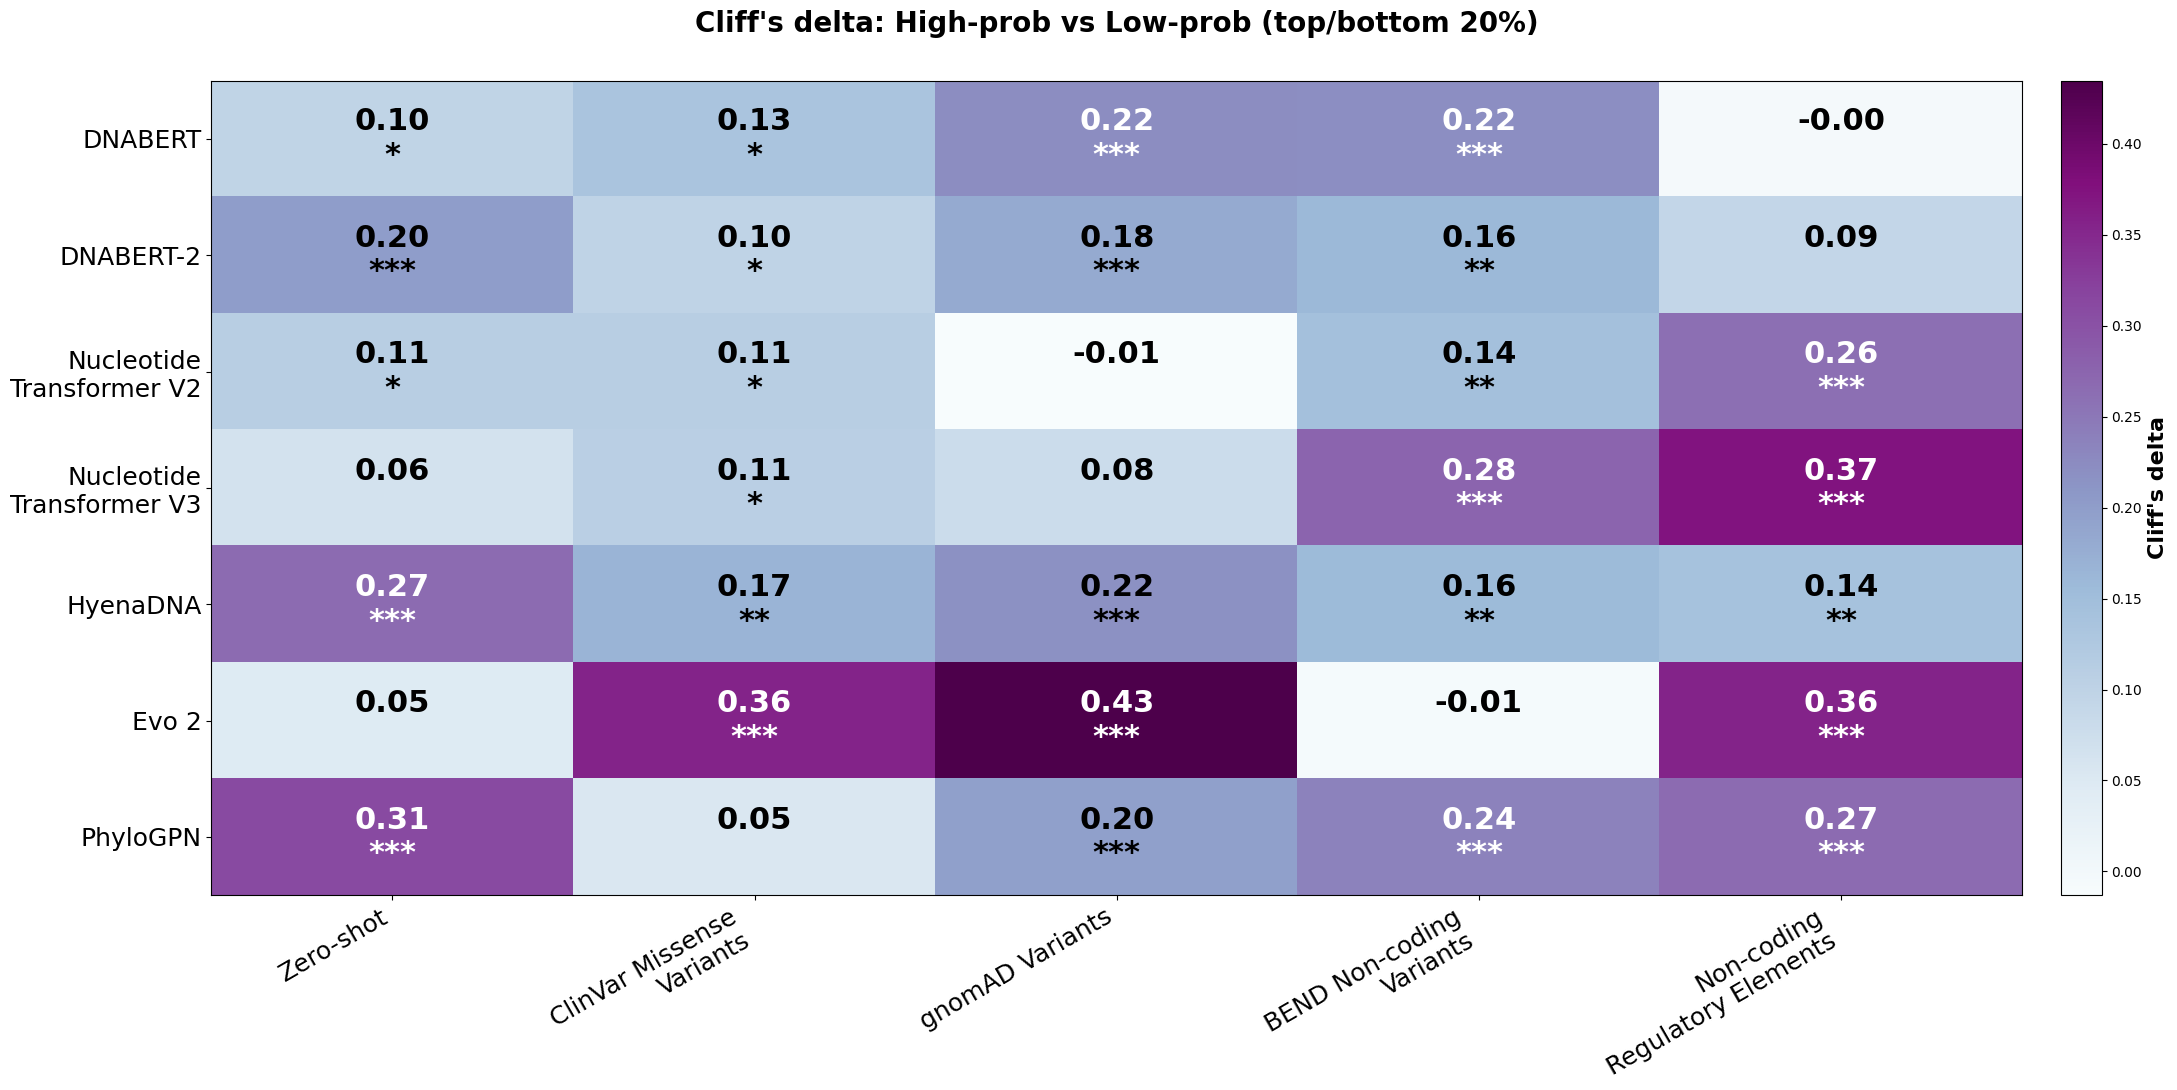

In [ ]:
v_cd = res_df.pivot(index="model", columns="task", values="cd").reindex(index=MODEL_KEYS, columns=TASK_KEYS)
q_m = res_df.pivot(index="model", columns="task", values="q_fdr").reindex(index=MODEL_KEYS, columns=TASK_KEYS)

y_labels = [MODEL_LABEL.get(m, m) for m in v_cd.index]
x_labels = [TASK_DISPLAY_MAP.get(t, t) for t in v_cd.columns]

plt.figure(figsize=(22, 11))
im = plt.imshow(v_cd.values, aspect="auto", cmap="BuPu")
plt.colorbar(im, pad=0.02, fraction=0.046).set_label("Cliff's delta", fontsize=16, fontweight='bold')

plt.yticks(range(len(y_labels)), y_labels, fontsize=18)
plt.xticks(range(len(x_labels)), x_labels, ha="right", fontsize=18, rotation=30)
plt.title(f"High-prob vs Low-prob (Top/Bottom {int(TARGET_FRAC*100)}%)", fontsize=20, fontweight="bold", pad=35)

# Text Annotation
vmax = np.nanmax(v_cd.values)
for i in range(v_cd.shape[0]):
    for j in range(v_cd.shape[1]):
        v = v_cd.values[i, j]
        if not np.isfinite(v): continue
        q = q_m.values[i, j]
        sig = "***" if q < 0.001 else "**" if q < 0.01 else "*" if q < 0.05 else ""
        color = "white" if v > (vmax * 0.5) else "black"
        plt.text(j, i-0.02, f"{v:.2f}", ha="center", va="bottom", fontweight="bold", color=color, fontsize=22)
        if sig: plt.text(j, i+0.02, sig, ha="center", va="top", fontweight="bold", color=color, fontsize=22)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "final_heatmap_20.png"), dpi=300, bbox_inches="tight")
plt.show()